
══════════════════════════════════════════════════════════════════════
  01_load_and_qc.py  |  43 files  |  UCSD ADCS VR Eye-Tracking
  Head trim: 0.0s  |  Analysis window: 120.0s
  Valid frame: pupil≥0.5mm AND openness≥0.2 (≥1 eye)
  Excluded: {'VR0560_1_EyeTrackingData_20250513_080932.csv'}
══════════════════════════════════════════════════════════════════════

  VR0171  [OK          ]  Hz= 73  133.3s→120.0s  invalid=0.0%  ★★★★★
  VR0418  [OK          ]  Hz= 72  119.5s→119.5s  invalid=0.2%  ★★★★★
  VR0423  [OK          ]  Hz= 73  134.9s→120.0s  invalid=0.3%  ★★★★★
  VR0439  [OK          ]  Hz= 76  125.8s→120.0s  invalid=1.6%  ★★★★★
  VR0456  [OK          ]  Hz= 73  146.7s→120.0s  invalid=0.1%  ★★★★★
  VR0492  [OK          ]  Hz= 71  133.6s→120.0s  invalid=0.0%  ★★★★★
  VR0497  [OK          ]  Hz= 72  130.4s→120.0s  invalid=0.0%  ★★★★★
  VR0505  [OK          ]  Hz= 56  138.9s→120.0s  invalid=0.0%  ★★★★★
  VR0513  [OK          ]  Hz= 74  133.4s→120.0s  invalid=0.0%  ★★★★★
  VR0515  [O

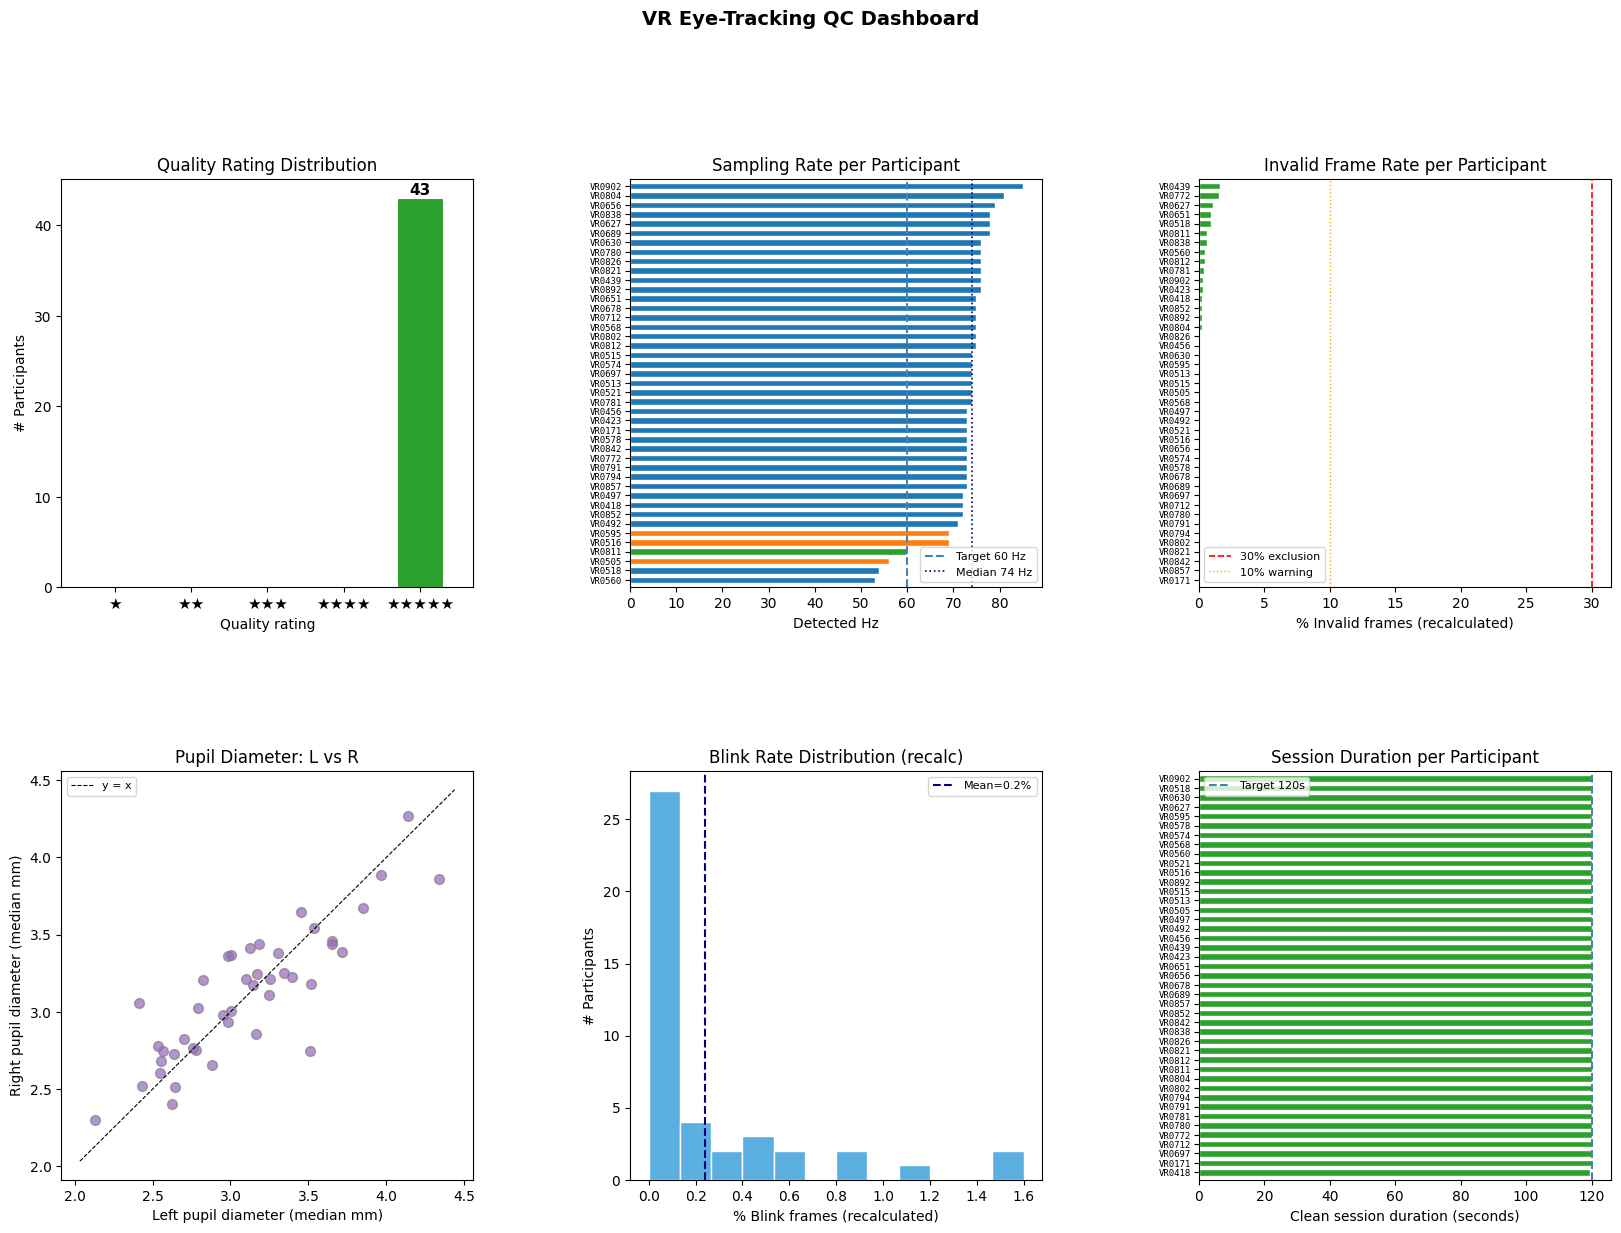

  Dashboard saved → /Users/cynthianyongesa/Desktop/Desktop - Cynthia's Macbook Pro/DATA/2_EYE_TRACKING_PY/Eye-Tracking Excel Files/_QC_OUTPUT/QC_dashboard.png
  QA report saved  → /Users/cynthianyongesa/Desktop/Desktop - Cynthia's Macbook Pro/DATA/2_EYE_TRACKING_PY/Eye-Tracking Excel Files/_QC_OUTPUT/QA_report.csv
  Cleaned files    → /Users/cynthianyongesa/Desktop/Desktop - Cynthia's Macbook Pro/DATA/2_EYE_TRACKING_PY/Eye-Tracking Excel Files/_CLEANED/

══════════════════════════════════════════════════════════════════════



In [7]:
# ============================================================
#  01_load_and_qc.py
#  VR Eye-Tracking — Load, QC, Clean, Dashboard
#  Cynthia Nyongesa | UCSD ADCS | IRB #803273
#
#  Run once. Outputs:
#    _QC_OUTPUT/QA_report.csv       — full per-participant QC table
#    _QC_OUTPUT/QC_dashboard.png    — 6-panel QC figure
#    _CLEANED/*.csv                 — trimmed + valid-frame-recalculated files
# ============================================================

# ── IMPORTS ──────────────────────────────────────────────────
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CONFIG — edit these, nothing else needs changing
# ═══════════════════════════════════════════════════════════════

CSV_DIR   = "/Users/cynthianyongesa/Desktop/Desktop - Cynthia's Macbook Pro/DATA/2_EYE_TRACKING_PY/Eye-Tracking Excel Files"
VIDEO_DIR = "/Users/cynthianyongesa/Desktop/Desktop - Cynthia's Macbook Pro/DATA/2_EYE_TRACKING_PY/Eye-Tracking Videos/ORIGINAL_MP4"
OUT_DIR   = os.path.join(CSV_DIR, "_QC_OUTPUT")
CLEAN_DIR = os.path.join(CSV_DIR, "_CLEANED")

# Session
HEAD_TRIM_S       = 0.0    # remove first N seconds (calibration settling)
TARGET_DURATION_S = 120.0   # exact analysis window after head trim
INVALID_THRESHOLD = 0.30    # exclude participant if > 30% invalid frames

# Valid frame thresholds (raw pupil + openness — bypasses broken Unity blink columns)
PUPIL_MIN      = 0.5        # mm; below = tracking loss
OPEN_MIN       = 0.2        # 0–1 openness; below = lid closed / blink
MIN_VALID_EYES = 1          # at least 1 eye must pass both thresholds

# Files to always exclude
EXCLUDE_FILES = {"VR0560_1_EyeTrackingData_20250513_080932.csv"}

# Column names
TS      = "Timestamp"
LOOKED  = "LookedObject"
GAZE_X  = "CentralEyeGazePositionX"
GAZE_Y  = "CentralEyeGazePositionY"
GAZE_Z  = "CentralEyeGazePositionZ"
YAW     = "CentralEyeRotationYaw"
PITCH   = "CentralEyeRotationPitch"
PUPIL_L = "LeftPupilDiameter"
PUPIL_R = "RightPupilDiameter"
OPEN_L  = "LeftEyeOpenness"
OPEN_R  = "RightEyeOpenness"
SACC_L  = "SaccadeLeft"

os.makedirs(OUT_DIR,   exist_ok=True)
os.makedirs(CLEAN_DIR, exist_ok=True)

# ═══════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════

def load_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    for sep in ["\t", ",", ";"]:
        try:
            df = pd.read_csv(path, sep=sep, low_memory=False)
            if df.shape[1] > 5:
                return df
        except Exception:
            continue
    raise ValueError("Could not parse file")


def detect_hz(df):
    try:
        ts = pd.to_numeric(df[TS], errors="coerce").dropna()
        diffs = ts.diff().dropna()
        diffs = diffs[diffs > 0]
        if len(diffs) < 10:
            return None
        med = diffs.median()
        hz  = round(1000 / med) if med > 1 else round(1.0 / med)
        return int(hz)
    except Exception:
        return None


def normalize_and_trim(df, hz):
    """
    1. Normalize timestamps to seconds from zero (handles ms and s).
    2. Remove first HEAD_TRIM_S seconds.
    3. Re-zero and keep exactly TARGET_DURATION_S seconds.
    Returns (trimmed_df, raw_duration_s, clean_duration_s).
    """
    ts = pd.to_numeric(df[TS], errors="coerce")
    if ts.median() > 1000:
        ts = ts / 1000.0
    ts = ts - ts.iloc[0]
    df = df.copy()
    df[TS] = ts

    raw_duration = round(float(ts.iloc[-1]), 1)

    # Head trim
    df = df[df[TS] >= HEAD_TRIM_S].copy()
    df[TS] = df[TS] - df[TS].iloc[0]

    # Tail trim to exactly TARGET_DURATION_S
    df = df[df[TS] <= TARGET_DURATION_S].copy()
    df = df.reset_index(drop=True)

    clean_duration = round(float(df[TS].iloc[-1]), 1) if len(df) > 0 else 0.0
    return df, raw_duration, clean_duration


def compute_valid_frames(df):
    """
    Recalculate validity from raw pupil + openness.
    Ignores potentially broken Unity BlinkLeft/BlinkRight columns.
    Adds: valid_L, valid_R, frame_valid, blink_recalc
    """
    df = df.copy()

    if PUPIL_L in df.columns and OPEN_L in df.columns:
        df["valid_L"] = (
            (pd.to_numeric(df[PUPIL_L], errors="coerce").fillna(0) >= PUPIL_MIN) &
            (pd.to_numeric(df[OPEN_L],  errors="coerce").fillna(0) >= OPEN_MIN)
        )
    else:
        df["valid_L"] = False

    if PUPIL_R in df.columns and OPEN_R in df.columns:
        df["valid_R"] = (
            (pd.to_numeric(df[PUPIL_R], errors="coerce").fillna(0) >= PUPIL_MIN) &
            (pd.to_numeric(df[OPEN_R],  errors="coerce").fillna(0) >= OPEN_MIN)
        )
    else:
        df["valid_R"] = False

    n_valid = df["valid_L"].astype(int) + df["valid_R"].astype(int)
    df["frame_valid"]  = n_valid >= MIN_VALID_EYES
    df["blink_recalc"] = ~df["frame_valid"]
    return df


def detect_red_flags(df, hz):
    flags = []

    # Gaze stuck at origin
    if all(c in df.columns for c in [GAZE_X, GAZE_Y, GAZE_Z]):
        zero_pct = ((df[GAZE_X]==0) & (df[GAZE_Y]==0) & (df[GAZE_Z]==0)).mean() * 100
        if zero_pct > 5:
            flags.append(f"Gaze (0,0,0) in {zero_pct:.1f}% of frames")

    # Head not moving
    if YAW in df.columns and df[YAW].std() < 0.5:
        flags.append(f"Yaw std={df[YAW].std():.3f}° — minimal head movement")

    # LookedObject mostly null
    if LOOKED in df.columns:
        null_pct = (df[LOOKED].isna() |
                    (df[LOOKED].astype(str).str.strip()=="") |
                    (df[LOOKED].astype(str)=="None")).mean() * 100
        if null_pct > 50:
            flags.append(f"LookedObject null in {null_pct:.1f}% of frames")

    # Pupil out of range
    if PUPIL_L in df.columns:
        p_med = pd.to_numeric(df[PUPIL_L], errors="coerce").median()
        if pd.notna(p_med) and p_med > 0 and (p_med < 1.5 or p_med > 9.0):
            flags.append(f"Left pupil median={p_med:.2f}mm (expected 2–8mm)")

    # Blink rate implausibly high
    if "blink_recalc" in df.columns and hz:
        blink_rate = (df["blink_recalc"].astype(int).diff()==1).sum() / TARGET_DURATION_S
        if blink_rate > 1.0:
            flags.append(f"Blink rate={blink_rate:.2f}/s (recalc) — suspiciously high")

    # Non-monotonic timestamps
    neg_steps = (df[TS].diff().dropna() < 0).sum()
    if neg_steps > 0:
        flags.append(f"{neg_steps} non-monotonic timestamp steps")

    # Hz far outside expected
    if hz and (hz < 40 or hz > 120):
        flags.append(f"Hz={hz} outside expected 40–120 range")

    return flags


def match_video(fname, video_dir):
    pid = fname.split("_")[0]
    for ext in [".mp4", ".MP4", ".mov", ".MOV", ".webm"]:
        hits = glob.glob(os.path.join(video_dir, f"{pid}_*{ext}"))
        if hits:
            return os.path.basename(hits[0])
    return "NOT FOUND"


def star_rating(pct_inv, hz):
    """Rate on invalid % only (frame count no longer meaningful due to variable Hz)."""
    if pct_inv is None:
        return 1, "★☆☆☆☆"
    score = 5.0
    if   pct_inv > 30: score -= 3.0
    elif pct_inv > 20: score -= 2.0
    elif pct_inv > 10: score -= 1.0
    elif pct_inv >  5: score -= 0.5
    if hz and (hz < 40 or hz > 120): score -= 0.5
    score = max(1, min(5, round(score)))
    return score, "★" * score + "☆" * (5 - score)


# ═══════════════════════════════════════════════════════════════
#  MAIN QC LOOP
# ═══════════════════════════════════════════════════════════════

all_files = sorted([
    f for f in
    glob.glob(os.path.join(CSV_DIR, "*.csv")) +
    glob.glob(os.path.join(CSV_DIR, "*.xlsx")) +
    glob.glob(os.path.join(CSV_DIR, "*.xls"))
    if os.path.basename(f) not in EXCLUDE_FILES
])

print(f"\n{'═'*70}")
print(f"  01_load_and_qc.py  |  {len(all_files)} files  |  UCSD ADCS VR Eye-Tracking")
print(f"  Head trim: {HEAD_TRIM_S}s  |  Analysis window: {TARGET_DURATION_S}s")
print(f"  Valid frame: pupil≥{PUPIL_MIN}mm AND openness≥{OPEN_MIN} (≥{MIN_VALID_EYES} eye)")
print(f"  Excluded: {EXCLUDE_FILES}")
print(f"{'═'*70}\n")

records = []

for path in all_files:
    fname = os.path.basename(path)
    pid   = fname.split("_")[0]
    rec   = dict(
        participant_id=pid, file=fname,
        n_frames_raw=None, hz=None,
        raw_duration_s=None, clean_duration_s=None, n_frames_clean=None,
        pct_invalid_clean=None, pct_blink_recalc=None,
        pupil_l_median=None, pupil_r_median=None,
        saccade_rate=None,
        star_score=None, stars=None,
        video=None, status="OK", flags="", n_flags=0
    )

    try:
        # 1. Load
        df = load_file(path)
        rec["n_frames_raw"] = len(df)

        # 2. Detect Hz
        hz = detect_hz(df)
        rec["hz"] = hz

        # 3. Normalize timestamps + trim (head 10s + tail to 120s)
        df, raw_dur, clean_dur = normalize_and_trim(df, hz)
        rec["raw_duration_s"]   = raw_dur
        rec["clean_duration_s"] = clean_dur
        rec["n_frames_clean"]   = len(df)

        # 4. Recalculate valid frames from raw pupil + openness
        df = compute_valid_frames(df)

        # 5. Invalid frame % (post-trim, recalculated)
        pct_inv = round((~df["frame_valid"]).mean() * 100, 1)
        rec["pct_invalid_clean"] = pct_inv
        rec["pct_blink_recalc"]  = round(df["blink_recalc"].mean() * 100, 1)

        # 6. Pupil medians
        if PUPIL_L in df.columns:
            rec["pupil_l_median"] = round(
                pd.to_numeric(df[PUPIL_L], errors="coerce").replace(0, np.nan).median(), 3)
            rec["pupil_r_median"] = round(
                pd.to_numeric(df[PUPIL_R], errors="coerce").replace(0, np.nan).median(), 3)

        # 7. Saccade rate
        if SACC_L in df.columns:
            saccades = (df[SACC_L].fillna(0).diff() == 1).sum()
            rec["saccade_rate"] = round(saccades / TARGET_DURATION_S, 2)

        # 8. Star rating
        score, stars = star_rating(pct_inv, hz)
        rec["star_score"] = score
        rec["stars"]      = stars

        # 9. Status
        if pct_inv > INVALID_THRESHOLD * 100:
            rec["status"] = "HIGH_INVALID"
        if clean_dur < TARGET_DURATION_S * 0.90:
            rec["status"] = "SHORT"

        # 10. Red flags
        flag_list      = detect_red_flags(df, hz)
        rec["flags"]   = " | ".join(flag_list)
        rec["n_flags"] = len(flag_list)

        # 11. Video match
        rec["video"] = match_video(fname, VIDEO_DIR)

        # 12. Save cleaned file
        df.to_csv(os.path.join(CLEAN_DIR, fname), index=False, sep="\t")

        # Print line
        flag_str = f"  ⚠ {len(flag_list)} flag(s)" if flag_list else ""
        print(f"  {pid}  [{rec['status']:<12}]  "
              f"Hz={hz or '?':>3}  "
              f"{raw_dur}s→{clean_dur}s  "
              f"invalid={pct_inv}%  "
              f"{stars}{flag_str}")
        for f in flag_list:
            print(f"       ↳ {f}")

    except Exception as e:
        rec["status"]  = "CORRUPTED"
        rec["flags"]   = str(e)
        rec["n_flags"] = 1
        print(f"  {pid}  [CORRUPTED]  {e}")

    records.append(rec)


# ═══════════════════════════════════════════════════════════════
#  SUMMARY
# ═══════════════════════════════════════════════════════════════

df_rec   = pd.DataFrame(records)
ok       = df_rec[df_rec["status"] == "OK"]
flagged  = df_rec[df_rec["status"] != "OK"]
stars5   = df_rec[df_rec["star_score"] == 5]
stars4p  = df_rec[df_rec["star_score"] >= 4]
red_flag = df_rec[df_rec["n_flags"] > 0]
hz_dist  = df_rec["hz"].dropna().value_counts().sort_index()

print(f"\n{'═'*70}")
print(f"  SUMMARY")
print(f"{'═'*70}")
print(f"  Files processed:          {len(df_rec)}")
print(f"  Status OK:                {len(ok)}")
print(f"  Flagged (status != OK):   {len(flagged)}")
print(f"  Files with red flags:     {len(red_flag)}")
print(f"  ★★★★★ star students:      {len(stars5)}")
print(f"  ★★★★+ usable:             {len(stars4p)}")

print(f"\n  Hz distribution:")
for hz_val, count in hz_dist.items():
    bar = "█" * int(count)
    print(f"    {hz_val:>4} Hz  {bar}  ({count})")

print(f"\n  Trim summary (all participants):")
print(f"    Removed:  first {HEAD_TRIM_S}s (calibration settling)")
print(f"    Kept:     {TARGET_DURATION_S}s analysis window")
print(f"    Mean clean duration: {df_rec['clean_duration_s'].mean():.1f}s")

inv = df_rec["pct_invalid_clean"].dropna()
print(f"\n  Invalid frames (post-trim, recalculated from raw pupil+openness):")
print(f"    Mean:   {inv.mean():.1f}%")
print(f"    Median: {inv.median():.1f}%")
print(f"    Max:    {inv.max():.1f}%  ({df_rec.loc[inv.idxmax(), 'participant_id']})")

if len(flagged):
    print(f"\n  EXCLUDED / FLAGGED:")
    for _, r in flagged.iterrows():
        print(f"    ✗ {r['participant_id']}  [{r['status']}]  {r['flags'][:80]}")

if len(red_flag):
    print(f"\n  RED FLAGS (review before analysis):")
    for _, r in red_flag.iterrows():
        print(f"    ⚠ {r['participant_id']}:")
        for f in r["flags"].split(" | "):
            print(f"       - {f}")

print(f"\n  NOTE: All analyses use TIMESTAMPS not frame indices.")
print(f"  Variable Hz ({int(df_rec['hz'].min())}–{int(df_rec['hz'].max())} Hz) is normal for")
print(f"  Unity render-loop logging. Timestamp-based windowing ensures")
print(f"  identical {TARGET_DURATION_S}s windows across all participants.")

print(f"\n  ➜ FINAL N FOR ANALYSIS: {len(ok)}")
print(f"{'═'*70}\n")


# ═══════════════════════════════════════════════════════════════
#  QC DASHBOARD  — 6 panels
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 13))
fig.suptitle("VR Eye-Tracking QC Dashboard", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel 1 — Star rating distribution
ax1 = fig.add_subplot(gs[0, 0])
star_counts = df_rec["star_score"].value_counts().reindex([1,2,3,4,5], fill_value=0)
color_map   = {1:"#d62728", 2:"#ff7f0e", 3:"#ffbb78", 4:"#98df8a", 5:"#2ca02c"}
bars = ax1.bar(star_counts.index, star_counts.values,
               color=[color_map[i] for i in star_counts.index],
               edgecolor="white", linewidth=0.8, width=0.6)
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(["★","★★","★★★","★★★★","★★★★★"], fontsize=11)
ax1.set_xlim(0.3, 5.7)
ax1.set_xlabel("Quality rating")
ax1.set_ylabel("# Participants")
ax1.set_title("Quality Rating Distribution")
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                 str(int(h)), ha="center", va="bottom", fontsize=11, fontweight="bold")

# Panel 2 — Sampling rate per participant
ax2 = fig.add_subplot(gs[0, 1])
df_hz      = df_rec[["participant_id","hz"]].dropna().sort_values("hz")
hz_vals    = df_hz["hz"].values
hz_labels  = df_hz["participant_id"].values
hz_colors  = ["#2ca02c" if 58<=h<=62 else "#ff7f0e" if 55<=h<58 or 62<h<=70 else "#1f77b4"
               for h in hz_vals]
ax2.barh(range(len(hz_vals)), hz_vals, color=hz_colors, edgecolor="white", height=0.7)
ax2.axvline(60, color="steelblue", linestyle="--", linewidth=1.5, label="Target 60 Hz")
ax2.axvline(float(np.median(hz_vals)), color="navy", linestyle=":", linewidth=1.2,
            label=f"Median {int(np.median(hz_vals))} Hz")
ax2.set_yticks(range(len(hz_vals)))
ax2.set_yticklabels(hz_labels, fontsize=6.5, fontfamily="monospace")
ax2.tick_params(axis="y", pad=2)
ax2.set_ylim(-0.8, len(hz_vals) - 0.2)
ax2.set_xlabel("Detected Hz")
ax2.set_title("Sampling Rate per Participant")
ax2.legend(fontsize=8)

# Panel 3 — Invalid frame % per participant (post-trim, recalculated)
ax3 = fig.add_subplot(gs[0, 2])
df_inv     = df_rec[["participant_id","pct_invalid_clean","star_score"]].dropna().sort_values("pct_invalid_clean")
inv_colors = ["#2ca02c" if s>=4 else "#ff7f0e" if s==3 else "#d62728"
               for s in df_inv["star_score"]]
ax3.barh(range(len(df_inv)), df_inv["pct_invalid_clean"], color=inv_colors, edgecolor="white", height=0.7)
ax3.axvline(30, color="red",    linestyle="--", linewidth=1.2, label="30% exclusion")
ax3.axvline(10, color="orange", linestyle=":",  linewidth=1.0, label="10% warning")
ax3.set_yticks(range(len(df_inv)))
ax3.set_yticklabels(df_inv["participant_id"], fontsize=6.5, fontfamily="monospace")
ax3.tick_params(axis="y", pad=2)
ax3.set_ylim(-0.8, len(df_inv) - 0.2)
ax3.set_xlabel("% Invalid frames (recalculated)")
ax3.set_title("Invalid Frame Rate per Participant")
ax3.legend(fontsize=8)

# Panel 4 — Pupil diameter L vs R
ax4 = fig.add_subplot(gs[1, 0])
pup = df_rec[["pupil_l_median","pupil_r_median"]].dropna()
if len(pup) > 1:
    ax4.scatter(pup["pupil_l_median"], pup["pupil_r_median"],
                alpha=0.7, color="#9467bd", edgecolors="grey", s=50)
    mn = pup.min().min() - 0.1
    mx = pup.max().max() + 0.1
    ax4.plot([mn, mx], [mn, mx], "k--", linewidth=0.8, label="y = x")
    ax4.set_xlabel("Left pupil diameter (median mm)")
    ax4.set_ylabel("Right pupil diameter (median mm)")
    ax4.set_title("Pupil Diameter: L vs R")
    ax4.legend(fontsize=8)

# Panel 5 — Blink rate distribution (recalculated)
ax5 = fig.add_subplot(gs[1, 1])
blink_data = df_rec["pct_blink_recalc"].dropna()
if len(blink_data) > 1:
    ax5.hist(blink_data, bins=12, color="#5aafe0", edgecolor="white")
    ax5.axvline(blink_data.mean(), color="navy", linestyle="--",
                label=f"Mean={blink_data.mean():.1f}%")
    ax5.set_xlabel("% Blink frames (recalculated)")
    ax5.set_ylabel("# Participants")
    ax5.set_title("Blink Rate Distribution (recalc)")
    ax5.legend(fontsize=8)

# Panel 6 — Session duration per participant
ax6 = fig.add_subplot(gs[1, 2])
df_dur     = df_rec[["participant_id","clean_duration_s"]].dropna().sort_values("clean_duration_s")
dur_vals   = df_dur["clean_duration_s"].values
dur_labels = df_dur["participant_id"].values
dur_colors = ["#2ca02c" if 115<=d<=125 else "#ff7f0e" if 100<=d<115 else "#d62728"
               for d in dur_vals]
ax6.barh(range(len(dur_vals)), dur_vals, color=dur_colors, edgecolor="white", height=0.7)
ax6.axvline(TARGET_DURATION_S, color="steelblue", linestyle="--", linewidth=1.5,
            label=f"Target {int(TARGET_DURATION_S)}s")
ax6.set_yticks(range(len(dur_vals)))
ax6.set_yticklabels(dur_labels, fontsize=6.5, fontfamily="monospace")
ax6.tick_params(axis="y", pad=2)
ax6.set_ylim(-0.8, len(dur_vals) - 0.2)
ax6.set_xlabel("Clean session duration (seconds)")
ax6.set_title("Session Duration per Participant")
ax6.legend(fontsize=8)

plt.tight_layout()
plot_path = os.path.join(OUT_DIR, "QC_dashboard.png")
plt.savefig(plot_path, dpi=600, bbox_inches="tight")
plt.show()
print(f"  Dashboard saved → {plot_path}")


# ═══════════════════════════════════════════════════════════════
#  SAVE REPORT
# ═══════════════════════════════════════════════════════════════

report_path = os.path.join(OUT_DIR, "QA_report.csv")
df_rec.to_csv(report_path, index=False)
print(f"  QA report saved  → {report_path}")
print(f"  Cleaned files    → {CLEAN_DIR}/")
print(f"\n{'═'*70}\n")